In [1]:
import pandas as pd
df = pd.read_csv("data.csv")
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [2]:
df.columns

Index(['Country', 'Age', 'Salary', 'Purchased'], dtype='object')

In [3]:
df.shape

(10, 4)

In [4]:
df.info

<bound method DataFrame.info of    Country   Age   Salary Purchased
0   France  44.0  72000.0        No
1    Spain  27.0  48000.0       Yes
2  Germany  30.0  54000.0        No
3    Spain  38.0  61000.0        No
4  Germany  40.0      NaN       Yes
5   France  35.0  58000.0       Yes
6    Spain   NaN  52000.0        No
7   France  48.0  79000.0       Yes
8  Germany  50.0  83000.0        No
9   France  37.0  67000.0       Yes>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [6]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,38.777778,63777.777778
std,7.693793,12265.579662
min,27.000000,48000.000000
25%,35.000000,54000.000000
50%,38.000000,61000.000000
75%,44.000000,72000.000000
max,50.000000,83000.000000


In [7]:
df['Salary'].mean()

np.float64(63777.77777777778)

In [8]:
df['Age'].mean()

np.float64(38.77777777777778)

In [9]:
df.isnull()

,Country,Age,Salary,Purchased
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,True,False
5,False,False,False,False
6,False,True,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [10]:
df.isnull().sum()

Country      0
Age          1
Salary       1
Purchased    0
dtype: int64

In [11]:
df.isna()

,Country,Age,Salary,Purchased
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,True,False
5,False,False,False,False
6,False,True,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [12]:
df.isnull().sum().sort_values()

Country      0
Purchased    0
Age          1
Salary       1
dtype: int64

In [13]:
df.drop_duplicates()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [14]:
df['Age'].fillna(df['Age'].mean())

0    44.000000
1    27.000000
2    30.000000
3    38.000000
4    40.000000
5    35.000000
6    38.777778
7    48.000000
8    50.000000
9    37.000000
Name: Age, dtype: float64

In [15]:
df['Age'].fillna(df.describe().loc['mean','Age'])


0    44.000000
1    27.000000
2    30.000000
3    38.000000
4    40.000000
5    35.000000
6    38.777778
7    48.000000
8    50.000000
9    37.000000
Name: Age, dtype: float64

In [16]:
# outliers--> by IQR method
df = df.select_dtypes(include = 'number')
q1 = df['Age'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)
print(q1)
print(q3)
iqr = q3-q1
print(iqr)
LB = q1-1.5*iqr
UB = q3+1.5*iqr
print(LB)
print(UB)

35.0
72000.0
71965.0
-107912.5
179947.5


<Axes: >

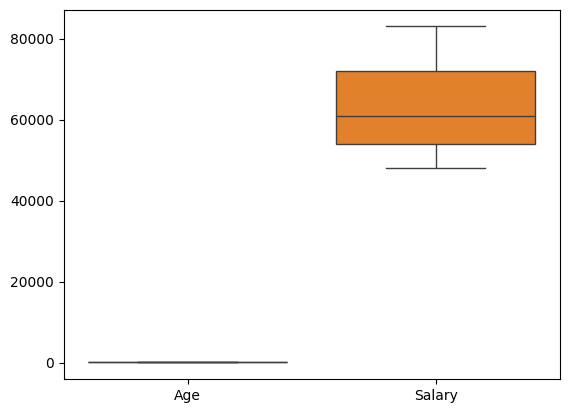

In [17]:
import seaborn as sns
sns.boxplot(df)

<Axes: ylabel='Salary'>

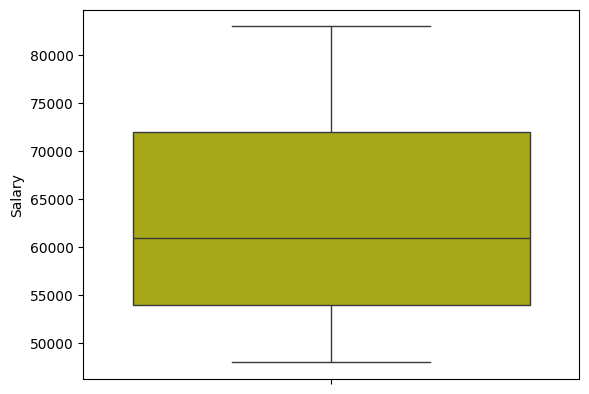

In [18]:
sns.boxplot(df['Salary'],color='y')

In [19]:
df1 = pd.read_csv("ecommerce_customers_unit1.csv")

In [20]:
df1

,customer_id,age,gender,country,signup_date,last_purchase_date,num_orders,total_spent,avg_order_value,recency_days,is_premium_member,device_type,preferred_category,churned
0,10001,56.0,Male,India,2022-01-27,2024-04-27,10,13273.25,1327.32,522,0,NaN,Home,0
1,10002,69.0,Other,UK,2025-01-12,2025-08-01,10,NaN,308.90,61,0,Mobile,Grocery,0
2,10003,46.0,Female,USA,2021-04-25,2021-06-01,5,3411.83,682.37,1583,0,NaN,NaN,0
3,10004,32.0,Male,India,2021-02-23,2023-09-22,5,4502.00,900.40,740,0,NaN,NaN,0
4,10005,60.0,Female,India,2021-06-07,2021-12-11,7,3842.10,548.87,1390,0,Tablet,Books,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,10358,25.0,Female,India,2023-09-04,2025-06-18,7,NaN,0.00,105,1,Mobile,Electronics,0
601,10117,50.0,Male,USA,2024-05-11,2024-11-08,4,3640.07,910.02,327,0,Mobile,Electronics,0
602,10599,46.0,Male,India,2020-12-01,2024-06-25,6,2176.22,362.70,463,1,Desktop,Electronics,0
603,10442,32.0,Female,UK,2023-12-20,2024-09-20,3,5478.65,1826.22,376,0,Mobile,Home,0


In [21]:
df1.shape

(605, 14)

In [22]:
df1.columns

Index(['customer_id', 'age', 'gender', 'country', 'signup_date',
       'last_purchase_date', 'num_orders', 'total_spent', 'avg_order_value',
       'recency_days', 'is_premium_member', 'device_type',
       'preferred_category', 'churned'],
      dtype='object')

In [23]:
df1 = df1.drop_duplicates()

In [24]:
df1.shape

(600, 14)